<a href="https://colab.research.google.com/github/naviyabharathwaj/CNN-and-Streamlit/blob/main/CNN_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Set dataset path
data_dir = "/content/flowers"

In [ ]:
# Display flower categories
class_names = os.listdir(data_dir)
print("Flower Categories:")
print(class_names)

Flower Categories:
['sunflower', 'daisy', 'rose', 'dandelion', 'tulip']


In [ ]:
# Load dataset
batch_size = 32
img_height = 180
img_width = 180
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4313 files belonging to 5 classes.
Using 3451 files for training.
Found 4313 files belonging to 5 classes.
Using 862 files for validation.


In [ ]:
# Display class names
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


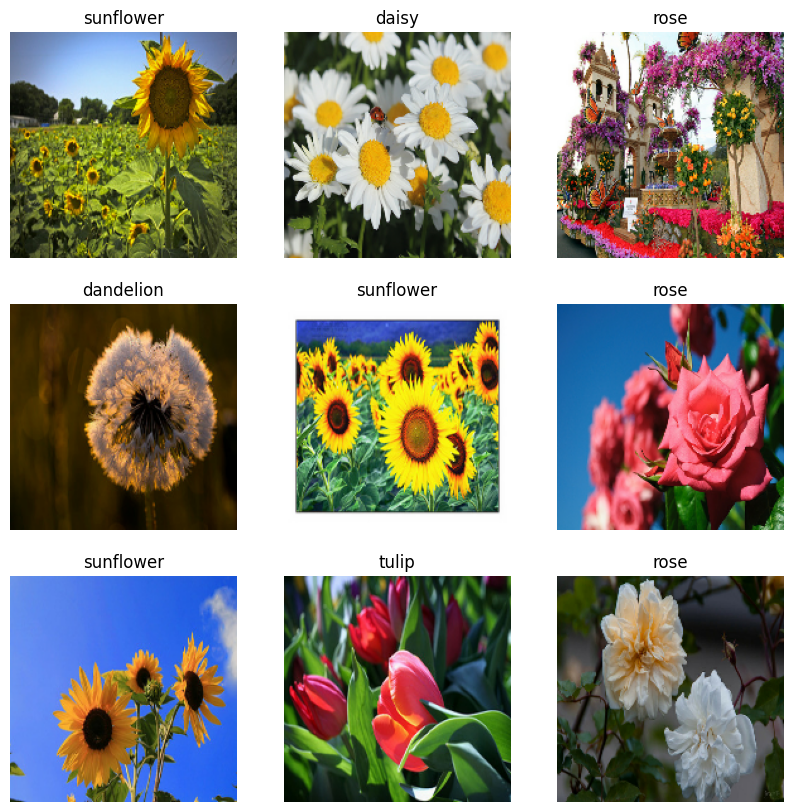

In [ ]:
# Display sample images
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# Build CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(180,180,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train model
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.4564 - loss: 1.2864 - val_accuracy: 0.5116 - val_loss: 1.1533
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.5949 - loss: 1.0137 - val_accuracy: 0.5742 - val_loss: 1.0292
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.6691 - loss: 0.8468 - val_accuracy: 0.6265 - val_loss: 0.9651
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.7386 - loss: 0.6667 - val_accuracy: 0.6497 - val_loss: 1.0086
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.8398 - loss: 0.4368 - val_accuracy: 0.6357 - val_loss: 1.1756
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.8971 - loss: 0.2843 - val_accuracy: 0.6160 - val_loss: 1.6448
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.9406 - loss: 0.1729 - val_accuracy: 0.6555 - val_loss: 1.5934
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9681 - loss: 0.0938 - val_accu

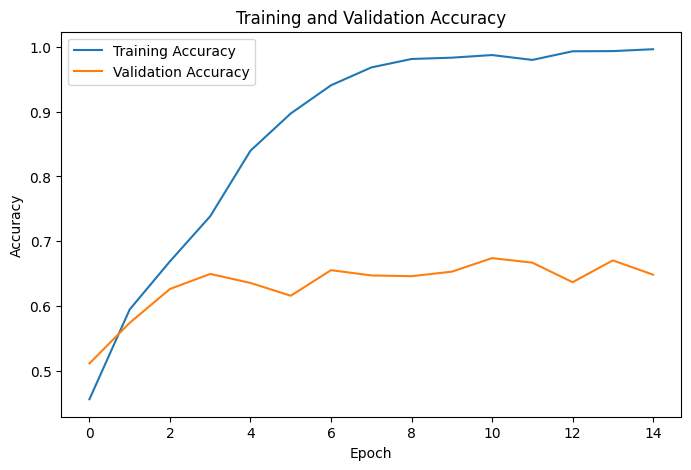

In [ ]:
# Plot Training Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

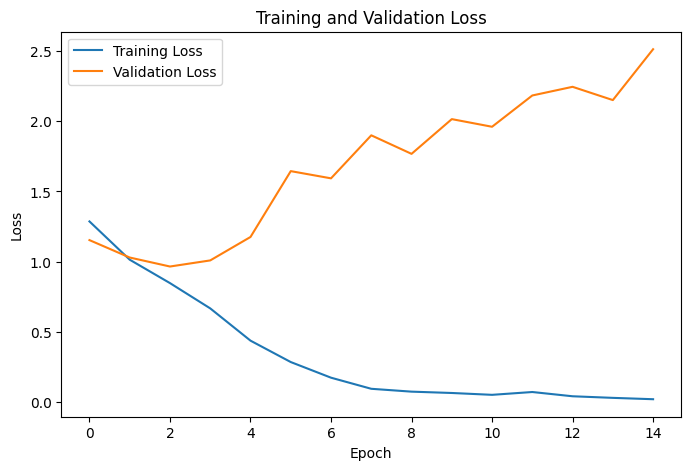

In [ ]:
# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Evaluate Model
loss, accuracy = model.evaluate(validation_ds)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 667ms/step - accuracy: 0.6485 - loss: 2.5135
Validation Loss: 2.513488531112671
Validation Accuracy: 0.6484918594360352


In [ ]:
model.save("flower_classifier.keras")